In [ ]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("itsmesunil/bank-loan-modelling")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bank-loan-modelling' dataset.
Path to dataset files: /kaggle/input/bank-loan-modelling


In [ ]:
import pandas as pd


file_path = '/content/Bank_Personal_Loan_Modelling.xlsx'
# Read all sheets into a dictionary
df = pd.read_excel(file_path, sheet_name="Data")
df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [ ]:
df.drop(columns=["ID", "ZIP Code"],inplace=True)

In [ ]:
y = df["Personal Loan"]
X = df.drop(columns=["Personal Loan"])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)

In [ ]:
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test_t  = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [ ]:
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

In [ ]:
input_dim = X_train.shape[1]
print("Input Features:", input_dim)

Input Features: 11


In [ ]:
def train_model(model, train_loader, X_test_t, y_test, epochs=200, lr=0.01):
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_accuracies = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for xb, yb in train_loader:
            preds = model(xb)
            loss = criterion(preds, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Evaluate accuracy on the test set after each epoch
        acc, _, _ = evaluate_model(model, X_test_t, y_test)
        test_accuracies.append(acc)

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_train_loss:.4f}, Test Accuracy: {acc:.4f}")

    return train_losses, test_accuracies

In [ ]:
def evaluate_model(model, X_test_t, y_test):
    model.eval()
    with torch.no_grad():
        probs = model(X_test_t).numpy().flatten()

    preds = (probs >= 0.5).astype(int)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    return acc, f1, preds

In [ ]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim, activation_fn):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            activation_fn,
            nn.Linear(32, 16),
            activation_fn,
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

activations = {
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU()
}

results = {}
metrics_history = {}

for name, act in activations.items():
    print("\n" + "="*60)
    print(f"Training MLP with Activation: {name}")
    print("="*60)

    model = MLP(input_dim=input_dim, activation_fn=act)

    train_losses, test_accuracies = train_model(model, train_loader, X_test_t, y_test, epochs=200, lr=0.01)

    acc, f1, preds = evaluate_model(model, X_test_t, y_test)

    results[name] = {"Accuracy": acc, "F1 Score": f1}
    metrics_history[name] = {"train_loss": train_losses, "test_accuracy": test_accuracies}

    print(f"\n {name} Results -> Accuracy: {acc:.4f}, F1: {f1:.4f}")


Training MLP with Activation: Sigmoid
Epoch 50/200, Loss: 0.0201, Test Accuracy: 0.9810
Epoch 100/200, Loss: 0.0065, Test Accuracy: 0.9770
Epoch 150/200, Loss: 0.0016, Test Accuracy: 0.9780
Epoch 200/200, Loss: 0.0002, Test Accuracy: 0.9780

 Sigmoid Results -> Accuracy: 0.9780, F1: 0.8866

Training MLP with Activation: Tanh
Epoch 50/200, Loss: 0.0076, Test Accuracy: 0.9880
Epoch 100/200, Loss: 0.0018, Test Accuracy: 0.9850
Epoch 150/200, Loss: 0.0003, Test Accuracy: 0.9880
Epoch 200/200, Loss: 0.0000, Test Accuracy: 0.9870

 Tanh Results -> Accuracy: 0.9870, F1: 0.9319

Training MLP with Activation: ReLU
Epoch 50/200, Loss: 0.0121, Test Accuracy: 0.9830
Epoch 100/200, Loss: 0.0021, Test Accuracy: 0.9800
Epoch 150/200, Loss: 0.0028, Test Accuracy: 0.9820
Epoch 200/200, Loss: 0.0009, Test Accuracy: 0.9800

 ReLU Results -> Accuracy: 0.9800, F1: 0.8936


In [ ]:
results_df = pd.DataFrame(results).T
print("\nFinal Comparison:\n")
print(results_df.sort_values(by="F1 Score", ascending=False))



Final Comparison:

         Accuracy  F1 Score
ReLU        0.983  0.910995
Sigmoid     0.979  0.890052
Tanh        0.978  0.888889


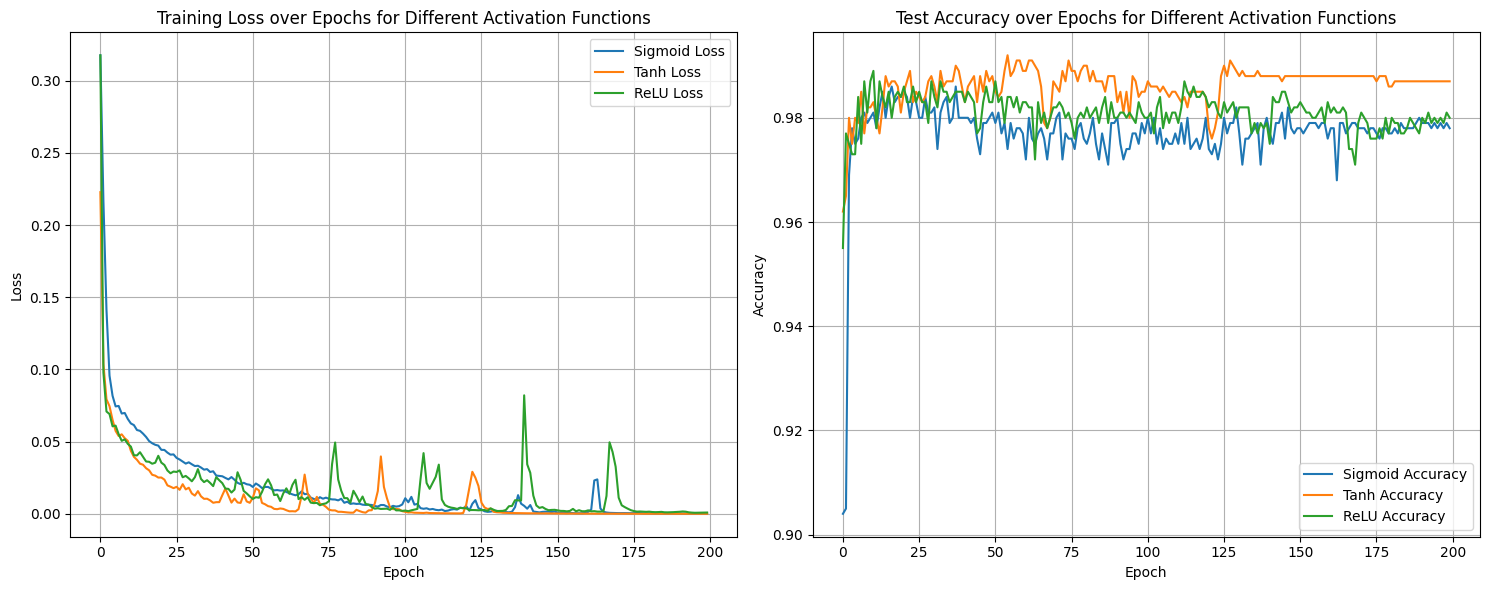

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

# Plot Training Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
for name, metrics in metrics_history.items():
    plt.plot(metrics["train_loss"], label=f'{name} Loss')
plt.title('Training Loss over Epochs for Different Activation Functions')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Test Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
for name, metrics in metrics_history.items():
    plt.plot(metrics["test_accuracy"], label=f'{name} Accuracy')
plt.title('Test Accuracy over Epochs for Different Activation Functions')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()